In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch_numopt
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.datasets import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, f1_score
from train_loop import train_loop

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [3]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=3, padding="same")
        self.maxpool = nn.MaxPool2d(3)
        self.fc1 = nn.Linear(200, 25)
        self.fc2 = nn.Linear(25, 2)

    def forward(self, x):
        x = torch.relu(self.conv(x))
        x = self.maxpool(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [12]:
# For CIFAR-10 binary classification (e.g., cats vs dogs)
transform_cifar = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

full_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_cifar)


# Filter and remap labels in one go
class RemappedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, class_map):
        self.dataset = dataset
        self.class_map = class_map
        self.indices = [i for i, (_, label) in enumerate(dataset) if label in class_map]

    def __len__(self):
        return len(self.indices)
        # return 800

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        return img, self.class_map[label]


# Use it
class_map = {3: 0, 5: 1}  # cat -> 0, dog -> 1
train_dataset = RemappedSubset(full_train, class_map)
# # Filter for two classes (e.g., class 3=cat, class 5=dog)
# train_indices = [i for i, (_, label) in enumerate(full_train) if label in [3, 5]]
# train_dataset = Subset(full_train, train_indices)

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [13]:
len(train_loader.dataset)

10000

In [14]:
xshape = train_dataset.dataset[0][0].shape
model = Net().to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch_numopt.AdaHessianLS(
    model=model,
    # solver="pinv-trunc",
    line_search_method="backtrack",
    line_search_cond="armijo",
    # damping="identity",
    # mu=1e-2,
)
# opt = torch_numopt.NewtonLS(
#     model=model,
#     solver="pinv-trunc",
#     line_search_method="backtrack",
#     line_search_cond="armijo",
#     damping="identity",
#     mu=1e-2,
# )

model, loss_history = train_loop(model, loss_fn, opt, train_loader, epochs=100, max_patience=10)

epoch:  0, loss: 0.7006368637084961
epoch:  1, loss: 0.6978451609611511
epoch:  2, loss: 0.6959968209266663
epoch:  3, loss: 0.6999885439872742
epoch:  4, loss: 0.7004856467247009
epoch:  5, loss: 0.700057864189148
epoch:  6, loss: 0.6983471512794495
epoch:  7, loss: 0.6976493000984192
epoch:  8, loss: 0.6993517875671387
epoch:  9, loss: 0.697557806968689
epoch:  10, loss: 15.94892692565918
epoch:  11, loss: 34.50465393066406
epoch:  12, loss: 0.7319960594177246
epoch:  13, loss: 0.7290375232696533
epoch:  14, loss: 0.738389790058136
epoch:  15, loss: 0.6968556642532349
epoch:  16, loss: 0.6976190805435181
epoch:  17, loss: 0.6990804672241211
epoch:  18, loss: 0.6969255208969116
epoch:  19, loss: 0.6967204809188843
epoch:  20, loss: 0.6997395157814026
epoch:  21, loss: 0.7001549601554871
epoch:  22, loss: 0.6986778974533081
epoch:  23, loss: 0.6971948146820068
epoch:  24, loss: 0.6972844004631042
epoch:  25, loss: 0.6972576975822449
epoch:  26, loss: 0.699917733669281
epoch:  27, loss:

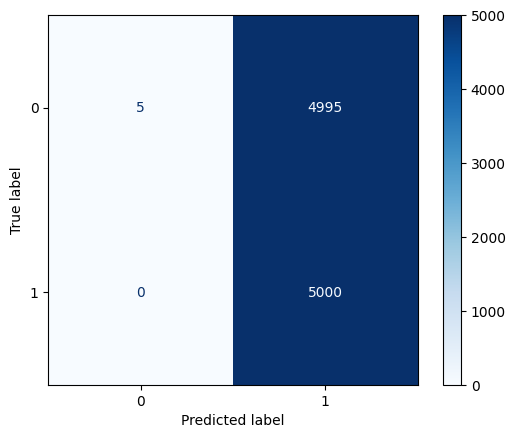

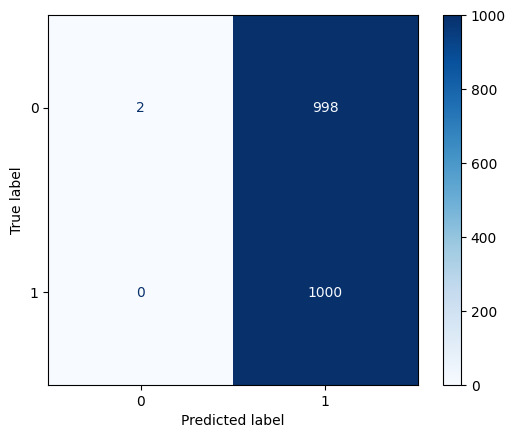

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

full_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
class_map = {3: 0, 5: 1}
test_dataset = RemappedSubset(full_test, class_map)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        y_true.append(y.cpu())
        y_pred.append(model(x).argmax(1).cpu())

ConfusionMatrixDisplay.from_predictions(torch.cat(y_true), torch.cat(y_pred), cmap="Blues")

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        y_true.append(y.cpu())
        y_pred.append(model(x).argmax(1).cpu())

ConfusionMatrixDisplay.from_predictions(torch.cat(y_true), torch.cat(y_pred), cmap="Blues")